# 08: HCMYO-A CE -> Subject Meta-Adaptation (3 runs, adapt=10%)

This notebook follows the same protocol as notebook `07`, but uses the dataset produced by preprocessing from:
- `code_bobr_678/data/preprocessing/preprocessing.ipynb`
- artifact: `code_bobr_678/data/datasets/hcmyo_preprocessed.npz`

Protocol:
1. In each run, train on two subjects.
2. On the third subject, split trials into `10% adapt` and `90% eval`.
3. Compare `pure zero-shot`, `pre-adapt proto`, and `adapted` modes.


## 1. Problem Setup and Math

### 1.1 Three Subject-Wise Runs

For subjects $\{S01,S02,S03\}$, construct 3 runs:
- train: $\{S01,S02\}$, target: $\{S03\}$
- train: $\{S01,S03\}$, target: $\{S02\}$
- train: $\{S02,S03\}$, target: $\{S01\}$

### 1.2 Split on the Target Subject

On the target subject (class-stratified):

$$
\text{adapt ratio} = 0.10,\quad
\text{eval ratio} = 0.90
$$

### 1.3 Stage A: Supervised CE

$$
\mathcal{L}_{CE} = -\frac{1}{B}\sum_{i=1}^{B}\log p_{\theta}(y_i\mid x_i)
$$

Monitoring metric: `val_adapt_monitor_f1` on source-only validation subjects (no target peeking).

### 1.4 Stage B: Prototypical Adaptation

$$
\mathbf{p}_c = \frac{1}{|S_c|}\sum_{(x,y)\in S_c} f_{\theta}(x),
\quad
\ell_c(x_q) = -\|f_{\theta}(x_q)-\mathbf{p}_c\|_2^2
$$

Episode loss:

$$
\mathcal{L}_{meta}=\mathrm{CE}(\ell(x_q), y_q)
$$

### 1.5 Main Metric

$$
F1_{macro} = \frac{1}{|\mathcal{C}|}\sum_{c\in\mathcal{C}} F1_c
$$


## 2. Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / 'data'
SRC_DIR = PROJECT_ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import notebook03_hcmyo_experiment_b_utils as exp8

exp8 = importlib.reload(exp8)


## 3. Configuration


In [2]:
HCMYO_NPZ = DATA_ROOT / 'datasets' / 'hcmyo_preprocessed.npz'
OUT_DIR = PROJECT_ROOT / 'reports' / 'artifacts' / 'notebook03'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PY = PROJECT_ROOT / 'models' / 'cnn_transformer_loso_v2.py'

ADAPT_RATIO = 0.10  # 10% for target adaptation

SUBJECT_NORM_CFG = {
    'clip': 6.0,
    'method': 'robust',
    'eps': 1e-6,
}

STAGEA_CFG = {
    'seed': 42,
    'device': 'cuda' if __import__('torch').cuda.is_available() else 'cpu',
    'epochs': 70,
    'batch_size': 64,
    'lr': 8e-4,
    'weight_decay': 1e-4,
    'patience': 12,
    'grad_clip': 1.0,
    'monitor': 'val_adapt_monitor_f1',
    'monitor_mode': 'max',
    'monitor_adapt_episodes': 40,
}

META_ADAPT_CFG = {
    'episodes': 80,
    'lr': 2.5e-4,
    'weight_decay': 1e-4,
    'grad_clip': 1.0,
    'embedding_norm': True,
    'n_way': 5,
    'k_shot': 6,
    'q_query': 6,
    'min_adapt_samples_for_train': 10,
    'min_q_query_for_train': 2,
}

MODEL_CFG = {
    'd_model': 64,
    'stride_cnn': 8,
    'k_cnn': 21,
    'n_heads': 4,
    'ff_dim': 256,
    'num_layers': 2,
    'dropout': 0.2,
}

print('HCMYO_NPZ:', HCMYO_NPZ)
print('OUT_DIR:', OUT_DIR)
print('ADAPT_RATIO:', ADAPT_RATIO)
print('DEVICE:', STAGEA_CFG['device'])


HCMYO_NPZ: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/data/datasets/hcmyo_preprocessed.npz
OUT_DIR: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/reports/artifacts/notebook03
ADAPT_RATIO: 0.1
DEVICE: cuda


## 4. Load Post-Crop Dataset and Build 3 Runs


In [3]:
exp8.set_seed(int(STAGEA_CFG['seed']))

ds = exp8.load_hcmyo_postcrop_varlen(HCMYO_NPZ)

subjects = np.asarray(ds['subject']).astype(str)
labels = np.asarray(ds['target'], dtype=np.int64)
lengths = np.asarray(ds['lengths'], dtype=np.int64)

runs = exp8.build_three_subject_runs(subjects)

print('samples:', len(labels))
print('subjects:', sorted(np.unique(subjects).tolist()))
print('n_classes:', len(np.unique(labels)), 'classes:', sorted(np.unique(labels).tolist()))
print('length stats:', {
    'min': int(lengths.min()),
    'median': float(np.median(lengths)),
    'mean': float(lengths.mean()),
    'max': int(lengths.max()),
})
print('n_runs:', len(runs))
for r in runs:
    print(r)

samples: 30000
subjects: ['S01', 'S02', 'S03']
n_classes: 10 classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
length stats: {'min': 510, 'median': 940.0, 'mean': 1052.4536666666668, 'max': 1590}
n_runs: 3
{'run_id': 1, 'target_subject': 'S01', 'train_subjects': ['S02', 'S03']}
{'run_id': 2, 'target_subject': 'S02', 'train_subjects': ['S01', 'S03']}
{'run_id': 3, 'target_subject': 'S03', 'train_subjects': ['S01', 'S02']}


## 5. EDA and Data Visualization


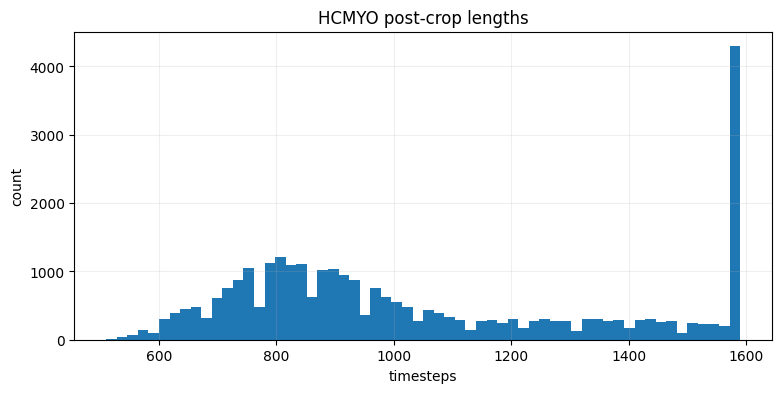

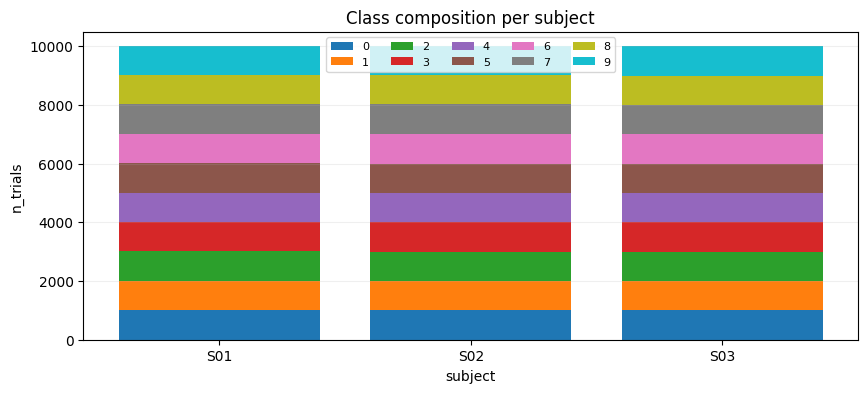

In [4]:
# Length distribution
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=60)
plt.title('HCMYO post-crop lengths')
plt.xlabel('timesteps')
plt.ylabel('count')
plt.grid(alpha=0.2)
plt.show()

# Class balance by subject
subj_sorted = sorted(np.unique(subjects).tolist())
class_ids = sorted(np.unique(labels).tolist())
mat = np.zeros((len(subj_sorted), len(class_ids)), dtype=np.int64)

for i, s in enumerate(subj_sorted):
    y_s = labels[subjects == s]
    for j, c in enumerate(class_ids):
        mat[i, j] = int(np.sum(y_s == c))

plt.figure(figsize=(10, 4))
bottom = np.zeros(len(subj_sorted), dtype=np.int64)
for j, c in enumerate(class_ids):
    plt.bar(np.arange(len(subj_sorted)), mat[:, j], bottom=bottom, label=str(c))
    bottom += mat[:, j]

plt.xticks(np.arange(len(subj_sorted)), subj_sorted)
plt.title('Class composition per subject')
plt.xlabel('subject')
plt.ylabel('n_trials')
plt.legend(ncol=5, fontsize=8)
plt.grid(axis='y', alpha=0.2)
plt.show()


## 6. Run CE -> Meta-Adaptation (adapt=10%)


In [5]:
ModelClass = exp8.load_model_class(MODEL_PY)

run_df, hist_df, summary = exp8.run_hcmyo_experiment_b(
    ds=ds,
    runs=runs,
    model_class=ModelClass,
    model_cfg=MODEL_CFG,
    stagea_cfg=STAGEA_CFG,
    meta_adapt_cfg=META_ADAPT_CFG,
    subject_norm_cfg=SUBJECT_NORM_CFG,
    adapt_ratio=float(ADAPT_RATIO),
    out_dir=OUT_DIR,
    save_checkpoints=False,
)

print(json.dumps(summary, indent=2, ensure_ascii=False))


[run 1] epoch=001/070 train_loss=2.0626 train_acc=0.2364 val0_f1=0.2133 valAmon_f1=0.2587
[run 1] epoch=002/070 train_loss=1.9151 train_acc=0.2979 val0_f1=0.2882 valAmon_f1=0.3219
[run 1] epoch=003/070 train_loss=1.7894 train_acc=0.3441 val0_f1=0.3312 valAmon_f1=0.3769
[run 1] epoch=004/070 train_loss=1.6723 train_acc=0.3929 val0_f1=0.4349 valAmon_f1=0.4032
[run 1] epoch=005/070 train_loss=1.5292 train_acc=0.4523 val0_f1=0.4661 valAmon_f1=0.4867
[run 1] epoch=006/070 train_loss=1.3899 train_acc=0.5073 val0_f1=0.5476 valAmon_f1=0.5740
[run 1] epoch=007/070 train_loss=1.2703 train_acc=0.5482 val0_f1=0.6329 valAmon_f1=0.6240
[run 1] epoch=008/070 train_loss=1.1862 train_acc=0.5866 val0_f1=0.6442 valAmon_f1=0.6310
[run 1] epoch=009/070 train_loss=1.1058 train_acc=0.6097 val0_f1=0.6618 valAmon_f1=0.6701
[run 1] epoch=010/070 train_loss=1.0384 train_acc=0.6348 val0_f1=0.6743 valAmon_f1=0.6899
[run 1] epoch=011/070 train_loss=0.9720 train_acc=0.6579 val0_f1=0.6674 valAmon_f1=0.6870
[run 1] ep

## 7. Results Analysis


In [6]:
cols = [
    'run', 'train_subjects', 'target_subject',
    'n_target_total', 'n_target_adapt', 'n_target_eval', 'adapt_ratio_realized',
    'test_zero_shot_f1_macro', 'test_pre_adapt_proto_f1_macro', 'test_adapt_f1_macro',
    'adapt_applied', 'skip_reason',
]
run_df[cols]


,run,train_subjects,target_subject,n_target_total,n_target_adapt,n_target_eval,adapt_ratio_realized,test_zero_shot_f1_macro,test_pre_adapt_proto_f1_macro,test_adapt_f1_macro,adapt_applied,skip_reason
0,1,"S02,S03",S01,10000,999,9001,0.0999,0.115143,0.368157,0.445444,1,
1,2,"S01,S03",S02,10000,1000,9000,0.1000,0.183514,0.489186,0.643162,1,
2,3,"S01,S02",S03,10000,1000,9000,0.1000,0.225623,0.463870,0.540327,1,


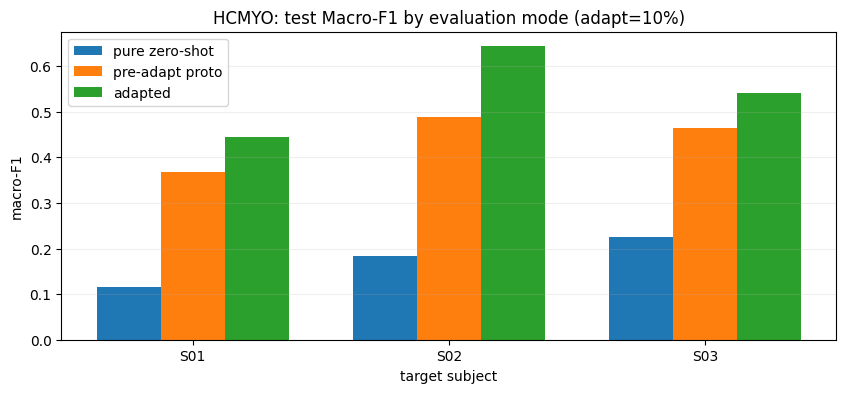

In [7]:
# F1 mode comparison across runs
plot_df = run_df.sort_values('run')
x = np.arange(len(plot_df))
w = 0.25

plt.figure(figsize=(10, 4))
plt.bar(x - w, plot_df['test_zero_shot_f1_macro'], width=w, label='pure zero-shot')
plt.bar(x,     plot_df['test_pre_adapt_proto_f1_macro'], width=w, label='pre-adapt proto')
plt.bar(x + w, plot_df['test_adapt_f1_macro'], width=w, label='adapted')
plt.xticks(x, plot_df['target_subject'].tolist())
plt.xlabel('target subject')
plt.ylabel('macro-F1')
plt.title('HCMYO: test Macro-F1 by evaluation mode (adapt=10%)')
plt.grid(axis='y', alpha=0.2)
plt.legend()
plt.show()


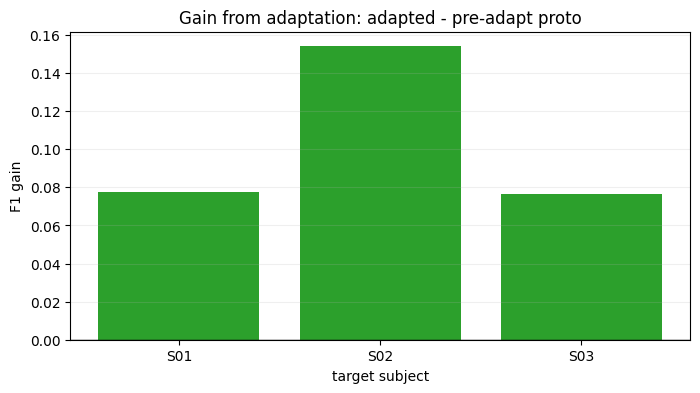

,run,target_subject,gain_adapt_vs_pre,adapt_ratio_realized,skip_reason
0,1,S01,0.077287,0.0999,
1,2,S02,0.153975,0.1000,
2,3,S03,0.076457,0.1000,


In [8]:
# Adaptation gain
run_df = run_df.copy()
run_df['gain_adapt_vs_pre'] = run_df['test_adapt_f1_macro'] - run_df['test_pre_adapt_proto_f1_macro']

plt.figure(figsize=(8, 4))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in run_df['gain_adapt_vs_pre']]
plt.bar(run_df['target_subject'], run_df['gain_adapt_vs_pre'], color=colors)
plt.axhline(0.0, color='black', linewidth=1)
plt.xlabel('target subject')
plt.ylabel('F1 gain')
plt.title('Gain from adaptation: adapted - pre-adapt proto')
plt.grid(axis='y', alpha=0.2)
plt.show()

run_df[['run', 'target_subject', 'gain_adapt_vs_pre', 'adapt_ratio_realized', 'skip_reason']]


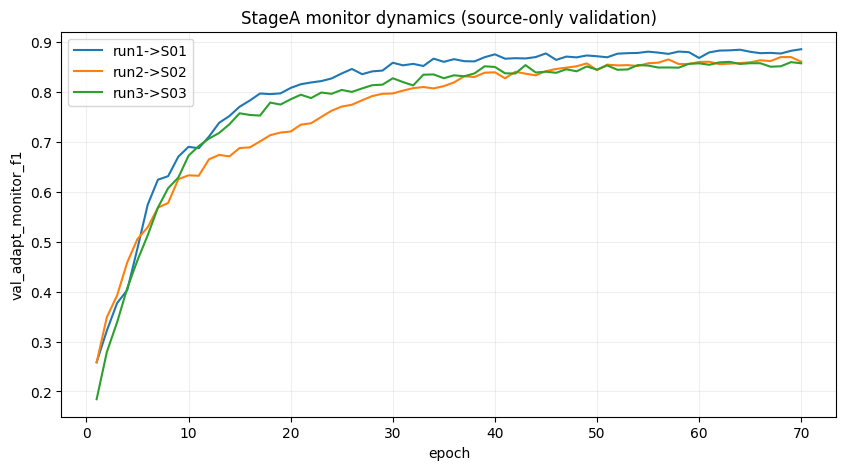

In [9]:
# StageA monitor dynamics
plt.figure(figsize=(10, 5))
for run_id, part in hist_df.groupby('run'):
    p = part.sort_values('epoch')
    target = run_df.loc[run_df['run'] == run_id, 'target_subject'].iloc[0]
    plt.plot(p['epoch'], p['val_adapt_monitor_f1'], label=f'run{int(run_id)}->{target}')

plt.xlabel('epoch')
plt.ylabel('val_adapt_monitor_f1')
plt.title('StageA monitor dynamics (source-only validation)')
plt.grid(alpha=0.2)
plt.legend()
plt.show()


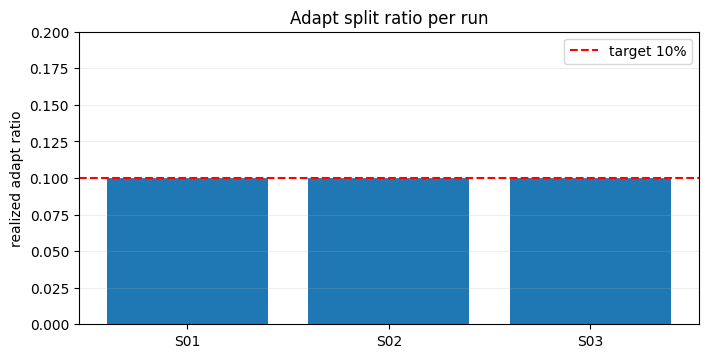

,target_subject,n_target_total,n_target_adapt,n_target_eval,adapt_ratio_realized
0,S01,10000,999,9001,0.0999
1,S02,10000,1000,9000,0.1000
2,S03,10000,1000,9000,0.1000


In [10]:
# Adaptation-ratio sanity check
plt.figure(figsize=(8, 3.8))
plt.bar(run_df['target_subject'], run_df['adapt_ratio_realized'])
plt.axhline(ADAPT_RATIO, linestyle='--', color='red', label='target 10%')
plt.ylim(0, 0.2)
plt.ylabel('realized adapt ratio')
plt.title('Adapt split ratio per run')
plt.grid(axis='y', alpha=0.2)
plt.legend()
plt.show()

run_df[['target_subject', 'n_target_total', 'n_target_adapt', 'n_target_eval', 'adapt_ratio_realized']]


## 8. Brief Conclusion

Check first:
- `test_adapt_f1_macro` vs `test_pre_adapt_proto_f1_macro` (does adaptation improve quality?),
- `adapt_ratio_realized` (should be close to 0.10),
- `skip_reason` (if adaptation was not applied).


## Data Split Protocol

**Protocol ID:** `notebook03_split_protocol_v2`  
**Experiment:** HCMYO-A low-budget target adaptation (3-run LOO)

- **Unit of split:**
  - outer split: subject-level leave-one-out over exactly 3 subjects;
  - inner split: target-subject trial-level split.
- **Stratification rule (inner split):** class-stratified by `target` within target subject.
- **Ratios:** `adapt_ratio=0.10` (adapt), remainder to `eval`.
- **Seed policy:** per-run seed `STAGEA_CFG['seed'] + run_id`; target split uses `run_seed + 17`.
- **Constraints/minimums:** for each class with >1 sample, both adapt and eval must be non-empty; for classes with 1 sample, sample goes to adapt by construction.
- **Stage A usage:** train on non-target subjects, monitor on source-only validation subjects (`val_adapt_monitor_f1`), with no target data in Stage A model selection.
- **Stage B usage:** adapt on target `adapt` trials; final test on target `eval` trials.


In [ ]:
# Auditable split protocol block
SPLIT_PROTOCOL_VERSION = 'notebook03_split_protocol_v2'

from pathlib import Path
import json
import numpy as np
import pandas as pd

AUDIT_OUT_DIR = PROJECT_ROOT / 'reports' / 'artifacts' / 'notebook03'
AUDIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

subjects_full = np.asarray(ds['subject']).astype(str)
y_full = np.asarray(ds['target'], dtype=np.int64)
unique_subjects = sorted(np.unique(subjects_full).tolist())

assert len(unique_subjects) == 3, f'Expected exactly 3 subjects, got {unique_subjects}'

run_rows = []
class_rows = []

for run in runs:
    run_id = int(run['run_id'])
    target_subj = str(run['target_subject'])
    train_subjects = [str(s) for s in run['train_subjects']]

    run_seed = int(STAGEA_CFG['seed']) + run_id

    train_idx = np.where(np.isin(subjects_full, train_subjects))[0].astype(np.int64)
    target_idx = np.where(subjects_full == target_subj)[0].astype(np.int64)

    adapt_idx, eval_idx, info = exp8.split_target_adapt_eval_stratified(
        y_full,
        target_idx,
        seed=run_seed + 17,
        adapt_ratio=float(ADAPT_RATIO),
    )

    assert len(adapt_idx) > 0 and len(eval_idx) > 0, f'empty adapt/eval split in run {run_id}'
    assert len(np.intersect1d(adapt_idx, eval_idx)) == 0, f'adapt/eval overlap in run {run_id}'

    realized = float(len(adapt_idx) / max(len(target_idx), 1))
    assert abs(realized - float(ADAPT_RATIO)) <= 0.02, (
        f'adapt ratio drift in run {run_id}: observed={realized:.4f} target={float(ADAPT_RATIO):.4f}'
    )

    run_rows.append({
        'run': run_id,
        'seed': run_seed,
        'train_subjects': ','.join(train_subjects),
        'target_subject': target_subj,
        'n_train': int(len(train_idx)),
        'n_target_total': int(len(target_idx)),
        'n_target_adapt': int(len(adapt_idx)),
        'n_target_eval': int(len(eval_idx)),
        'adapt_ratio_target': float(ADAPT_RATIO),
        'adapt_ratio_realized': realized,
    })

    cls_vals = sorted(np.unique(y_full[target_idx]).tolist())
    for cls in cls_vals:
        cls_target_idx = target_idx[y_full[target_idx] == int(cls)]
        cls_adapt = np.intersect1d(adapt_idx, cls_target_idx)
        cls_eval = np.intersect1d(eval_idx, cls_target_idx)
        if len(cls_target_idx) > 1:
            assert len(cls_adapt) > 0 and len(cls_eval) > 0, (
                f'class {cls} not split into both adapt/eval in run {run_id}'
            )
        class_rows.append({
            'run': run_id,
            'target_subject': target_subj,
            'class': int(cls),
            'n_total': int(len(cls_target_idx)),
            'n_adapt': int(len(cls_adapt)),
            'n_eval': int(len(cls_eval)),
        })

split_summary_df = pd.DataFrame(run_rows).sort_values('run').reset_index(drop=True)
class_distribution_df = pd.DataFrame(class_rows).sort_values(['run', 'class']).reset_index(drop=True)

protocol_payload = {
    'protocol_id': SPLIT_PROTOCOL_VERSION,
    'experiment': 'notebook03_hcmyo_three_run_loo_adaptation',
    'outer_split': {
        'unit': 'subject',
        'design': '3-run leave-one-subject-out over exactly 3 subjects',
        'subjects': unique_subjects,
    },
    'inner_split': {
        'unit': 'trial',
        'stratification': 'class-stratified within target subject',
        'adapt_ratio': float(ADAPT_RATIO),
        'seed_rule': 'run_seed + 17',
        'run_seed_rule': 'STAGEA_CFG.seed + run_id',
    },
    'stage_usage': {
        'stageA': {
            'train': 'non-target subjects',
            'monitor': 'source-only validation monitor val_adapt_monitor_f1 (no target peeking)'
        },
        'stageB': {
            'adapt': 'target adapt trials',
            'final_test': 'target eval trials'
        }
    },
    'constraints': {
        'non_empty_adapt_eval': True,
        'ratio_tolerance_assert': 0.02,
        'class_gt1_split_required': True,
    }
}

split_summary_csv = AUDIT_OUT_DIR / 'split_summary.csv'
class_distribution_csv = AUDIT_OUT_DIR / 'split_class_distribution.csv'
protocol_json = AUDIT_OUT_DIR / 'split_protocol.json'

split_summary_df.to_csv(split_summary_csv, index=False)
class_distribution_df.to_csv(class_distribution_csv, index=False)
protocol_json.write_text(json.dumps(protocol_payload, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved:', split_summary_csv)
print('Saved:', class_distribution_csv)
print('Saved:', protocol_json)

display(split_summary_df)
display(class_distribution_df.head(30))


NameError: name 'PROJECT_ROOT' is not defined